# Homework (15 points)

In this homework we train Sound Event Detection model.

Dataset: https://disk.yandex.ru/d/NRpDIp4jg2ODqg

In [1]:
!pip install torchaudio numpy tqdm matplotlib

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import requests
import tqdm.notebook as tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as torch_data
import torchaudio
import urllib

# implementation of Dataset for given data|
import dataset

from IPython.display import clear_output

%matplotlib inline

In [3]:
import requests
from urllib.parse import urlencode
from io import BytesIO
from tarfile import TarFile
import tarfile

base_url = 'https://cloud-api.yandex.net/v1/disk/public/resources/download?'
public_key = 'https://disk.yandex.ru/d/NRpDIp4jg2ODqg'
dst_path = '/home/jupyter/mnt/datasets/sound_event_detection/dataset/' # if we make the Datasphere datasets work
dst_path = './dataset/'

final_url = base_url + urlencode(dict(public_key=public_key))
response = requests.get(final_url)
download_url = response.json()['href']

# # if you aren't in the Datasphere
# !wget -O data.tar.gz  "{download_url}"
# !tar -xf data.tar.gz

# otherwise
# response = requests.get(download_url)
# io_bytes = BytesIO(response.content)
# tar = tarfile.open(fileobj=io_bytes, mode='r:gz')
# tar.extractall(path=dst_path)


In [4]:
DEVICE = 'cuda' # also you can use "cuda" for gpu and "mps" for apple silicon
DATADIR = 'data'
LOADER_WORKERS = 0

In [5]:
# FBANK 80 by default, but you can choose something else
FEATS = 80
transform_train = nn.Sequential(
    torchaudio.transforms.MelSpectrogram(n_mels=FEATS),
    # torchaudio.transforms.AmplitudeToDB(),
    # augmentation(1)
)
transform_test = nn.Sequential(
    torchaudio.transforms.MelSpectrogram(n_mels=FEATS),
    # torchaudio.transforms.AmplitudeToDB()
)
trainset = dataset.Dataset('train', DATADIR, transform_train)
testset = dataset.Dataset('eval', DATADIR, transform_test)
N_CLASSES = trainset.classes()

### Eval part (1 point)

Write balanced accuracy:
$$BAcc = \frac{1}{classes}\sum_{c = 1}^{classes} \frac{\sum_i^n I(y_i = p_i = c)}{\sum_i^n I(y_i = c)}$$

Where:
- $y_i$ -- target class for $i$ element
- $p_i$ -- predicted class for $i$ element

In [6]:
# Get list of pairs (target_class, predicted_class)
from collections import defaultdict
def balanced_accuracy(items: list[tuple[int, int]]) -> float:
    total_per_class = defaultdict(int)
    correct_per_class = defaultdict(int)

    for y_true, y_pred in items:
        total_per_class[y_true] += 1
        if y_true == y_pred:
            correct_per_class[y_true] += 1

    recalls = []
    for c in total_per_class:
        recalls.append(correct_per_class[c] / total_per_class[c])

    return sum(recalls) / len(recalls)


In [7]:
assert np.isclose(balanced_accuracy([(0, 0), (0, 0), (1, 1)]), 1.0)
assert np.isclose(balanced_accuracy([(0, 1), (1, 0)]), 0.0)
assert np.isclose(balanced_accuracy([(0, 0), (0, 0), (1, 0)]), 0.5)
assert np.isclose(balanced_accuracy([(0, 0), (1, 1), (0, 0), (0, 0), (1, 0), (0, 1)]), 0.625)
assert np.isclose(balanced_accuracy([(1, 1), (0, 1), (2, 2)]), 0.66666666666666)

### Train part (14 points)

Train some model with test accuracy > 0.5

You can train any model you want. The only limitations are
    1) it must be trained from scratch on the data provided in the task
    2) it must have less than 5M parameters

For example you can choose model from:
- DNN
- CNN 1d
- CNN 2d
- Transformer
- RNN
- mixes of given models

You can draw inspiration from the big models and build your own small model from scratch.

Hints:
- No need to train large models for this task. 5 million parameters is much more than you need.
- The score can be achieved by models with less than 100K params
- Take the feature dimension into account
- Monitor overfitting, try to add Augmentation, Dropout, BatchNorm, L1/L2-Regulatization or something else.
- Score of 0.35 is easily achievable by CNN 1d
- Use poolings or strides to reduce time-dimenstion. It is better to reduce the dimension gradually rather than at the end.
- Pay attention to the time dimension at the end of the network. How big is the receptive field of the network?
- Try different features (mel-spec, log-mel-spec, mfcc)
- You may need more than 10 epochs. One would would consider 20-30 epochs as a reasonable estimate
- You may need to use smaller batches)

P.S. Points can be subtracted for unclear training charts. Keep all the experiments that you've run in the notebook.

PP.S. It is sufficient for your model to beat the threshold once. We imagine a) there is a hidden best checkpoint save option and b) that the distribution of the test used to monitor the training is identical to the distribution of all possible tests)

PPP.S. A partial score will be awarded for a test accuracy < 0.5. Score of 0.35 is easily achievable by CNN 1d

PPPP.S. Add log to Melspectrogram in torchaudio.transform

In [8]:
from torch.amp import autocast

def get_num_params(model):
    result = 0
    for param in model.parameters():
        result += param.numel()
    return result


def stage(
    model: nn.Module,
    data: dataset.Dataset,
    opt: optim.Optimizer,
    scheduler,
    batch_size: int = 256,
    train: bool = True
):
    loader = torch_data.DataLoader(
        data,
        batch_size=batch_size,
        shuffle=True,
        num_workers=LOADER_WORKERS,
        collate_fn=dataset.collate_fn
    )
    if train:
        model.train()
    else:
        model.eval()
    loss_sum, batches = 0.0, 0
    pred_pairs = []
    for X, Y in tqdm.tqdm(loader):
        X = X.to(DEVICE, non_blocking=True)
        Y = Y.to(DEVICE, non_blocking=True)
        with autocast(device_type='cuda', dtype=torch.bfloat16):
          pred = model(X)
          loss = F.cross_entropy(pred.squeeze(), Y.squeeze())
        if train:
            opt.zero_grad()
            loss.backward()
            opt.step()
            scheduler.step()
        loss_sum += loss.item()
        batches += 1
        with torch.no_grad():
          pred_pairs.extend(zip(
              Y.cpu().numpy().reshape(-1),
              torch.argmax(pred, dim=1).cpu().numpy().reshape(-1)
          ))
    return loss_sum / batches, balanced_accuracy(pred_pairs)

import math
from torch.optim.lr_scheduler import LambdaLR

def train(
    model: nn.Module,
    opt,
    batch_size: int = 256,
    epochs: int = 10,
):
    train_loader = torch_data.DataLoader(
        trainset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=8,
        collate_fn=dataset.collate_fn
    )

    total_steps = epochs * len(train_loader)
    warmup_steps = int(0.05 * total_steps)

    def lr_lambda(step):
        if step < warmup_steps:
            return step / warmup_steps
        progress = (step - warmup_steps) / (total_steps - warmup_steps)
        return 0.5 * (1 + math.cos(math.pi * progress))

    scheduler = LambdaLR(opt, lr_lambda)

    train_losses, test_losses, train_accs, test_accs = [], [], [], []
    for epoch in range(epochs):
        train_loss, train_acc = stage(model, trainset, opt, scheduler,  batch_size=batch_size)
        test_loss, test_acc = stage(model, testset, opt,  scheduler, batch_size=batch_size, train=False)
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        test_losses.append(test_loss)
        test_accs.append(test_acc)
        clear_output()
        fig, axis = plt.subplots(1, 2, figsize=(15, 7))
        axis[0].plot(np.arange(1, epoch + 2), train_losses, label='train')
        axis[0].plot(np.arange(1, epoch + 2), test_losses, label='test')
        axis[1].plot(np.arange(1, epoch + 2), train_accs, label='train')
        axis[1].plot(np.arange(1, epoch + 2), test_accs, label='test')
        axis[0].set(xlabel='epoch', ylabel='CE Loss')
        axis[1].set(xlabel='epoch', ylabel='Accuracy')
        fig.legend()
        plt.show()
        print(f'Epoch {epoch + 1}.')
        print(f'Train loss {train_loss}. Train accuracy {train_acc}.')
        print(f'Test loss {test_loss}. Test accuracy {test_acc}')

In [9]:
# class DepthwiseSeparable(nn.Module):
#     def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0):
#         super().__init__()
#         self.depthwise = nn.Conv2d(
#             in_channels=in_channels,
#             out_channels=in_channels,
#             kernel_size=kernel_size,
#             stride=stride,
#             padding=padding,
#             groups=in_channels, # <- this parametr seperates convs to attend only to its group
#             bias=False
#         )

#         # karnel is one and output will be also one, groups is 1 by default
#         self.pointwise = nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=1, bias=False)


#     def forward(self, X):
#         return self.pointwise(self.depthwise(X))
# # it is unused as it is too lose for attention (my goal is whisper enocer like model)

import torchaudio.transforms as T

# thiis augentation prevents the overfitting the main barier in my attention
class SpecAugment(nn.Module):
    def __init__(self, time_mask_param=20, freq_mask_param=10):
        super().__init__()
        self.time_mask = T.TimeMasking(time_mask_param)
        self.freq_mask = T.FrequencyMasking(freq_mask_param)
    
    def forward(self, spec):
        spec = self.time_mask(spec)   # mask random time segments
        spec = self.freq_mask(spec)   # mask random frequency segments
        return spec

# instead we will use ConvXNet from this paper (better for transformer) https://arxiv.org/pdf/2201.03545
class ConvNeXtBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()

        self.dw = nn.Conv2d(dim, dim, 7, padding=3, groups=dim)
        self.norm = nn.LayerNorm(dim, eps=1e-6)

        self.pw1 = nn.Linear(dim, 4*dim)
        self.act = nn.GELU()
        self.pw2 = nn.Linear(4*dim, dim)

    def forward(self,x):

        residual = x

        x = self.dw(x)

        x = x.permute(0,2,3,1)
        x = self.norm(x)

        x = self.act(self.pw1(x))
        x = self.pw2(x)

        x = x.permute(0,3,1,2)

        return x + residual


class ConvNeXtFrontend(nn.Module):
    def __init__(self, dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, dim, kernel_size=3, stride=(1, 1), padding=1),  
            nn.GELU(),
            ConvNeXtBlock(dim),

            nn.Conv2d(dim, dim, kernel_size=3, stride=(2, 1), padding=1),
            nn.GELU(),
            ConvNeXtBlock(dim),
        )
        self.out_dim = dim

    def forward(self, x):
        return self.net(x)

class Attn_Enc(nn.Module):
    def __init__(self, dim, heads=4, ffn_mult=4, dropout=0.1):
        super().__init__()
        self.norm1 = nn.RMSNorm(dim)
        self.attn  = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=heads,
            batch_first=True,
            dropout=dropout
        )

        self.norm2 = nn.RMSNorm(dim) # <- better than LayerNorm
        self.ffn = nn.Sequential(
            nn.Linear(dim, dim * ffn_mult),
            nn.GELU(), # <- better than ReLU for transformers
            nn.Linear(dim * ffn_mult, dim),
            nn.Dropout(dropout) # <- dropout after standard
        )

    def forward(self, x):
        h,_ = self.attn(self.norm1(x), self.norm1(x), self.norm1(x)) #<- pass as K,Q,V and use pre norm better than past norm
        x = x + h # <- residual connections to scaqle normally

        x = x + self.ffn(self.norm2(x))
        return x

class AttentionPool(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(dim, dim // 4),
            nn.Tanh(),
            nn.Linear(dim // 4, 1, bias=False)
        )
    
    def forward(self, x):
        scores = self.attention(x)
        weights = F.softmax(scores, dim=1)
        return (x * weights).sum(dim=1)


class Model(nn.Module):
    def __init__(self, in_dim=FEATS, out_dim=N_CLASSES, d_model=128, max_len=1000):
        super().__init__()

        self.front = ConvNeXtFrontend(d_model)

        self._flat_dim = self._get_conv_output_size(in_dim)
        self.proj = nn.Linear(self._flat_dim, d_model)

        # time embeddings
        self.time_emb = nn.Embedding(max_len, d_model)

        self.encoder = nn.Sequential(
            Attn_Enc(d_model),
            Attn_Enc(d_model),
            Attn_Enc(d_model),
            Attn_Enc(d_model),
            Attn_Enc(d_model),
            Attn_Enc(d_model),
        )

        self.head = nn.Sequential( #<- base LM head but not tied to the embeddings as we have none
            nn.RMSNorm(d_model),
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(0.05), # <-usually smaller than overall dropout
            nn.Linear(d_model, out_dim)
        )

        self.pool = AttentionPool(d_model)
        self.spec_augment = SpecAugment(time_mask_param=30, freq_mask_param=15)

    def _get_conv_output_size(self, in_dim):
        with torch.no_grad():
            x = torch.zeros(1, 1, in_dim, 100) 
            x = self.front(x)
            _, C, H, W = x.shape
            return C * H

    def forward(self, X):
        if self.training:
            X = self.spec_augment(X)
        B, D, T = X.shape
        X = X.unsqueeze(1)         
        X = self.front(X)               
        _, C, Df, Tf = X.shape

        X = X.permute(0,3,1,2)      
        X = X.reshape(B, Tf, C*Df)      

        X = self.proj(X)         

        # adding time embeddings
        time_idx = torch.arange(Tf, device=X.device).unsqueeze(0)
        X = X + self.time_emb(time_idx)                      

        X = self.encoder(X)

        X = self.pool(X)                  # time pooling, simple mean (enough I think)

        return self.head(X)


In [10]:
model = Model().to(device=DEVICE)
print("Number of parameters is ", get_num_params(model))
opt = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01, betas=(0.9, 0.98)) #<- more stable AdamW but we (several of us observerd a problem with it! like spices in the middle of the training "unstable" while simple Adam was stabale)
# param count is ~300k < 1M failed at 35%
# params ~820k < 1M failed at 45% (more FFN less layers) (find out that for audio task FFn dim is not too important) after 15 epoch started to overfit
# params ~800 < 1M (5 layers, 64 model_d, 2x FFN) 46% ok it seems that this is not achivable with <1M params (using attention) so I will switch to <3M limit
# params ~822k < 1M (6 layers, 64 model_d, 2x FFN, added augmentation to not overfit) 45% fail

# maybe batch problem (128->32, + increase model size)

# param ~2M < 5M (6 layers, 128 model_d, 2x FFN, added augmentation to not overfit) 49% fail
# param ~2.4M < 5M (6 layers, 128 model_d, 4x FFN, added augmentation to not overfit) 49% fail no change

Number of parameters is  2421854


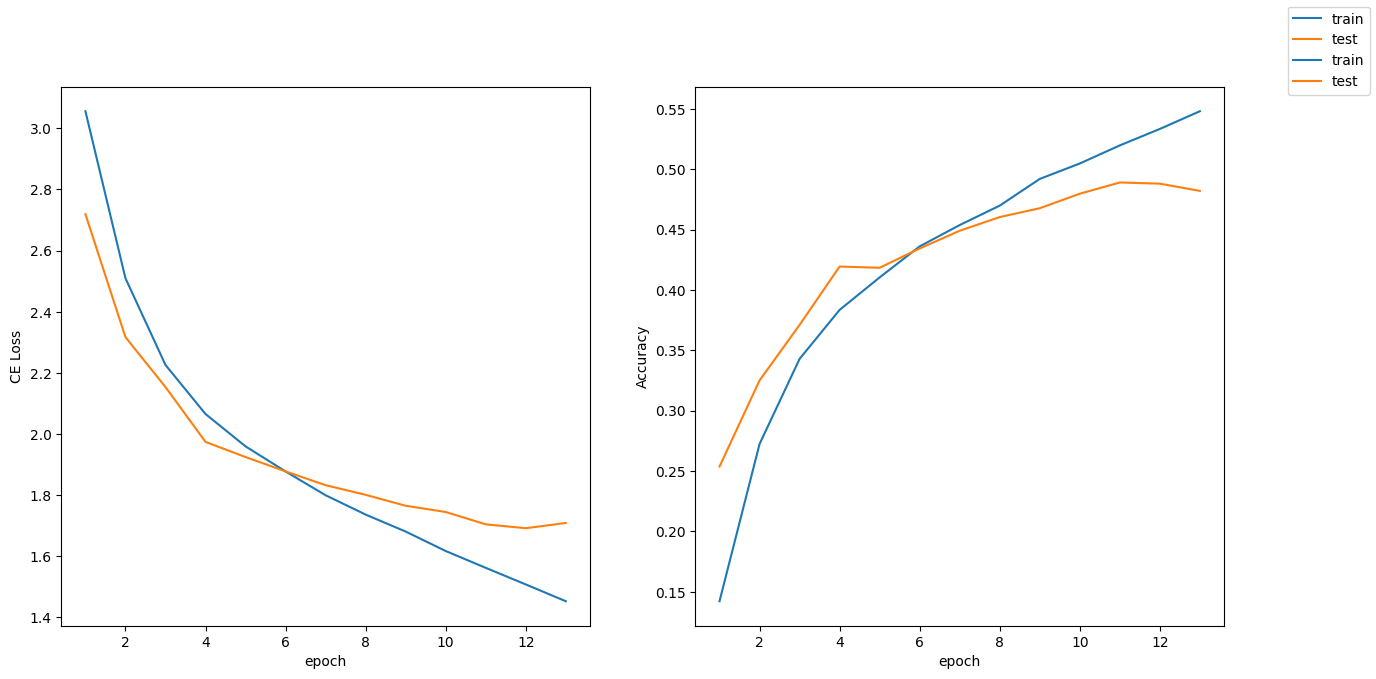

Epoch 13.
Train loss 1.4519769979686272. Train accuracy 0.5480169662170382.
Test loss 1.7081857082691598. Test accuracy 0.48200000000000004


  0%|          | 0/820 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [11]:
train(model, opt, batch_size = 32, epochs = 30)



In [12]:
# !pip install ipywidgets
# !jupyter nbextension enable --py widgetsnbextension
# !pip install torchcodec
# !pip install ipywidgets widgetsnbextension jupyterlab_widgets --upgrade

In [1]:
# I tried to do something like whisper (cnn on sound to get descrete tokens), encoder (to get meaning), and one
# FFN (2 layer with activation, for getting final class predition)
# pre norm applied

# as this is a transformer we can see that loss of validation was higher at the beginning then it began to
# losse to the train loss (this is common) due to dropout or regularization (weight decay). but as far as it is lowering with train loss and not getting
# higher it is not overfitting and we can continue to train.

# for ransformer pre_training warmup is essential!!! as Adam weights should gain magnitude and momentum (for stable convergence)

# It is interesting that at 6th epoch it reaches plateu in accuracy and then continoues to improvove,
# I observed this behaviour in the loss of LLM training. In this stage model is already learned all easy tasks
# and starts to actually learn high level paterns.

# positional embeddings were added, as Attention has no way to see the order, opposed to RNN's


In [ ]:

# I DO NOT KNOW WHY BUT IT IS NOT PASSING 50% ACCURACY ON ANY ARCHITECTURE AND SIZE (<5M)

0.0
0.038149010033189636
0.07629802006637927
0.11444703009956891
0.15259604013275854
0.1907450501659482
0.22889406019913783
0.2670430702323275
0.3051920802655171
0.34334109029870674
0.3814901003318964
0.419639110365086
0.45778812039827566
0.4959371304314653
0.534086140464655
0.5722351504978446
0.6103841605310342
0.6485331705642239
0.6866821805974135
0.7248311906306031
0.7629802006637928
0.8011292106969824
0.839278220730172
0.8774272307633617
0.9155762407965513
0.953725250829741
0.9918742608629306


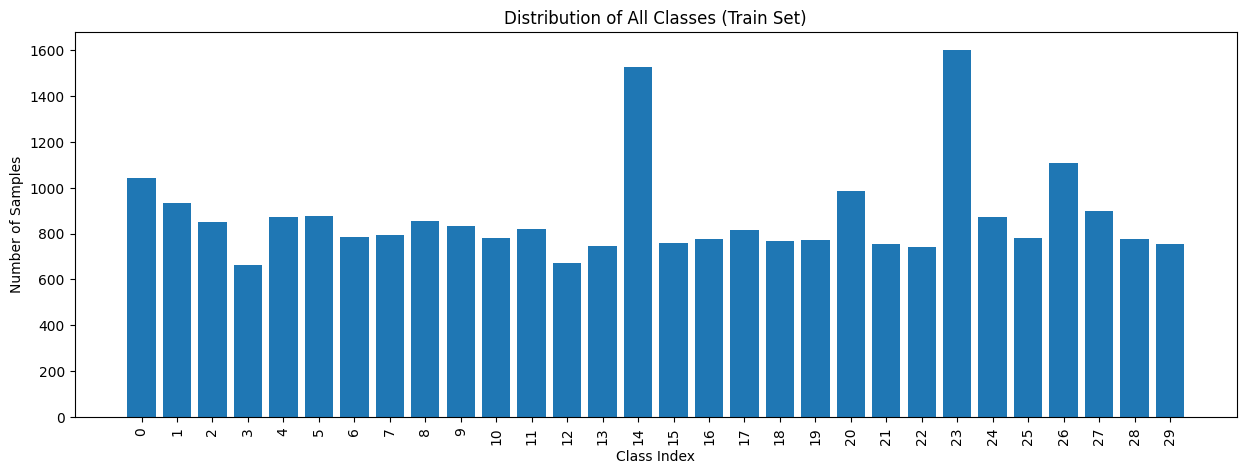

In [33]:
import matplotlib.pyplot as plt


classes = {}
for i in range(len(trainset)):
    if i % 1000 == 0:
        print(i/len(trainset))
    label = int(trainset[i][1])
    if label not in classes:
        classes[label] = 0
    classes[label] += 1

class_indices = sorted(classes.keys())
counts = [classes[i] for i in class_indices]

# Bar chart
plt.figure(figsize=(15,5)) 
plt.bar(class_indices, counts)
plt.xlabel("Class Index")
plt.ylabel("Number of Samples")
plt.title("Distribution of All Classes (Train Set)")
plt.xticks(class_indices, rotation=90)
plt.show()

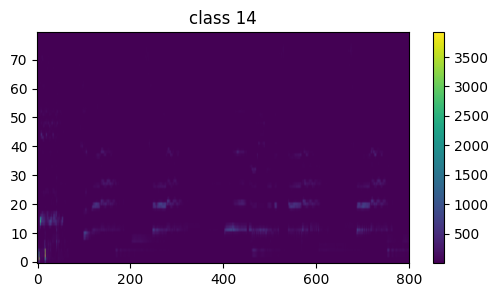

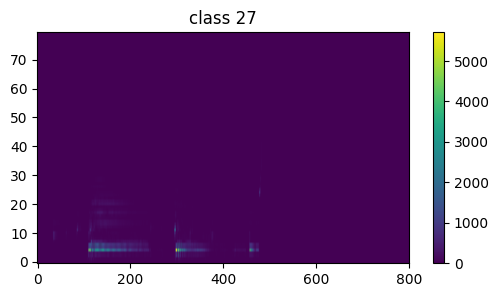

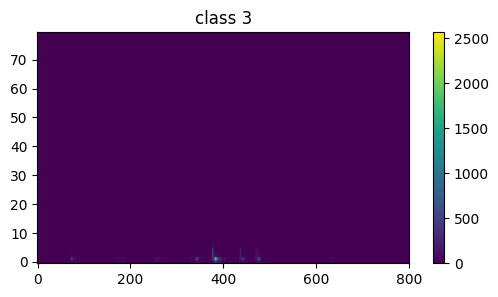

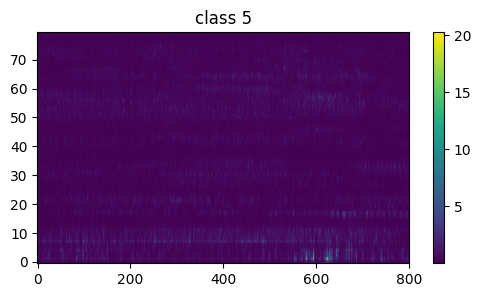

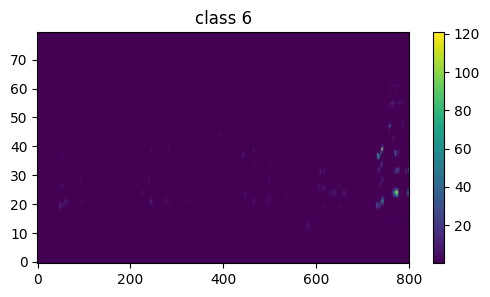

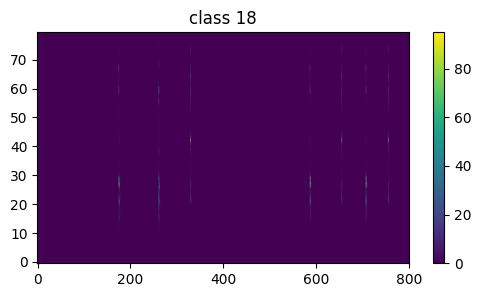

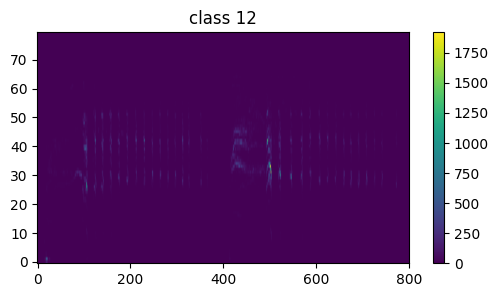

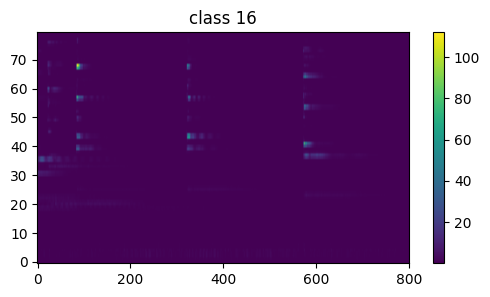

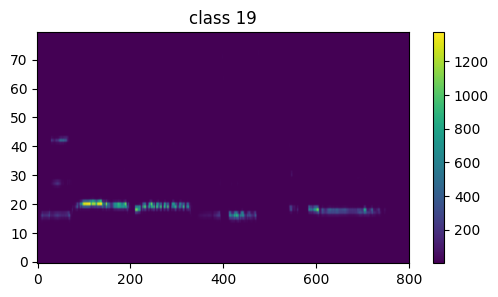

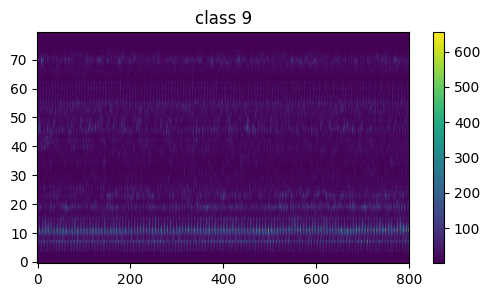

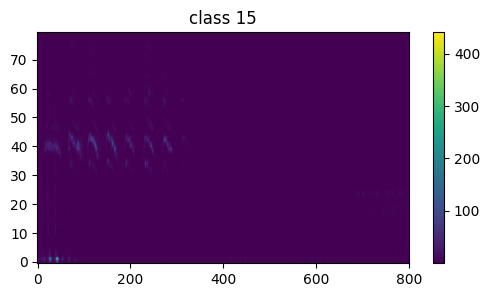

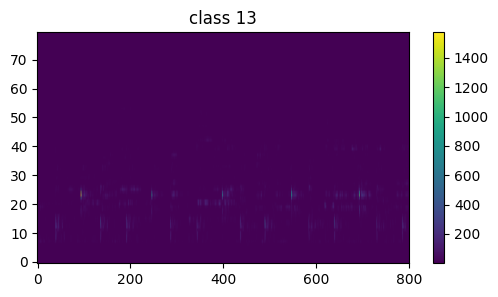

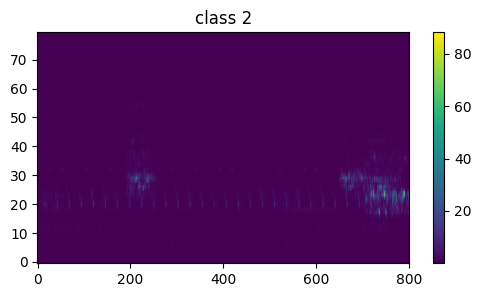

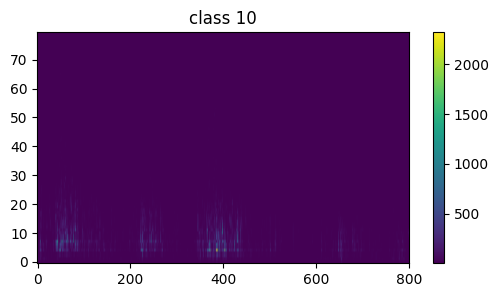

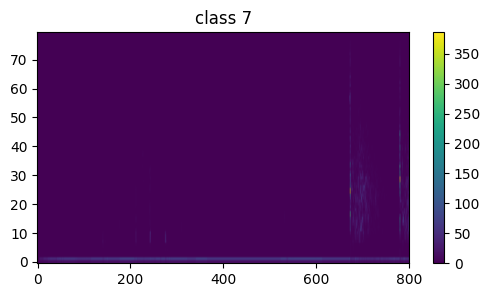

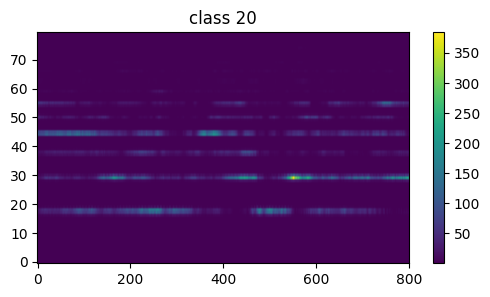

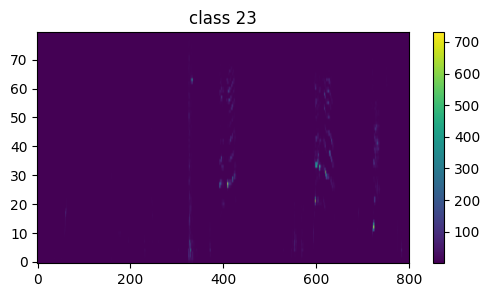

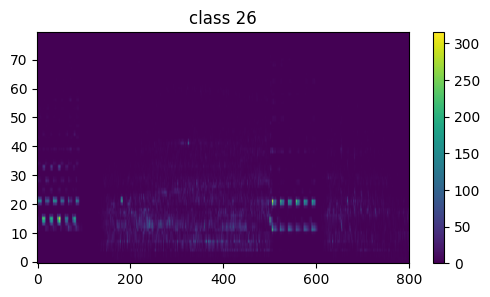

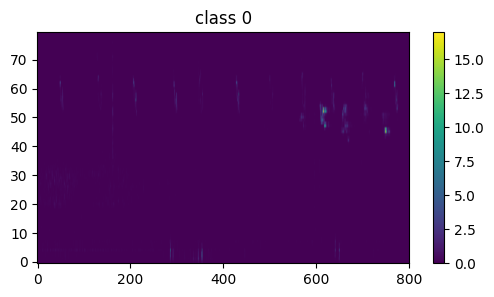

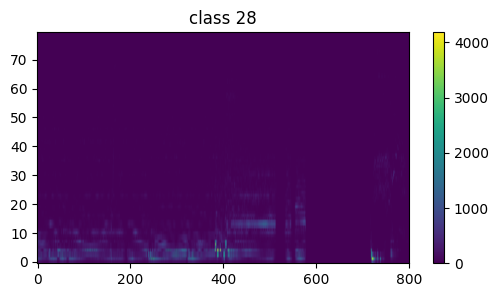

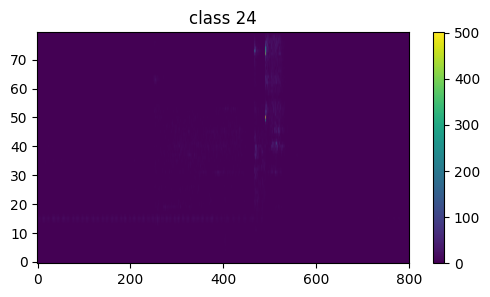

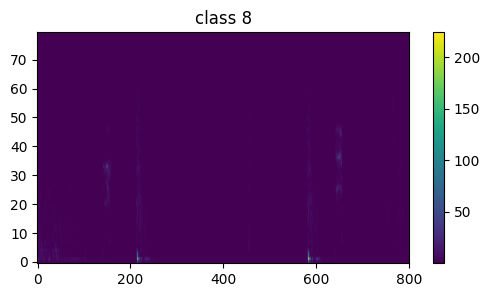

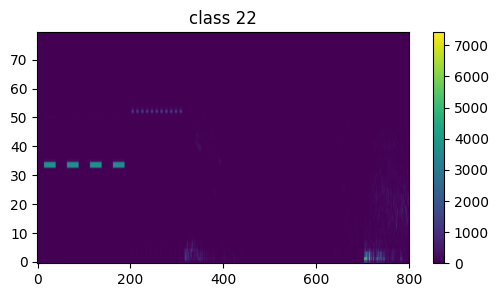

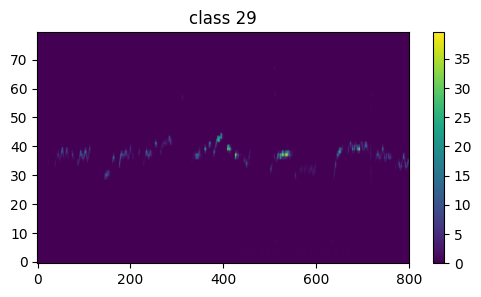

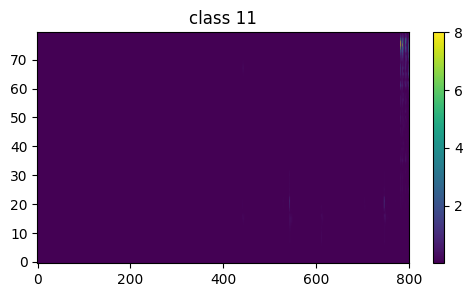

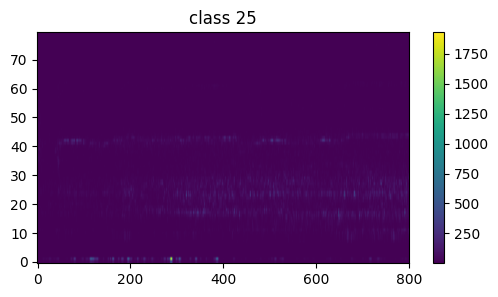

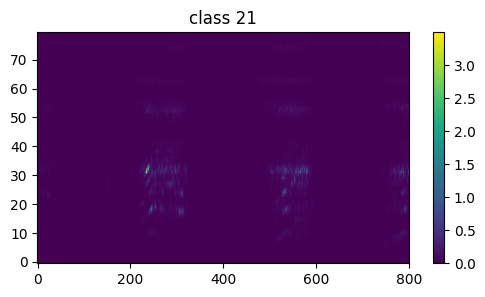

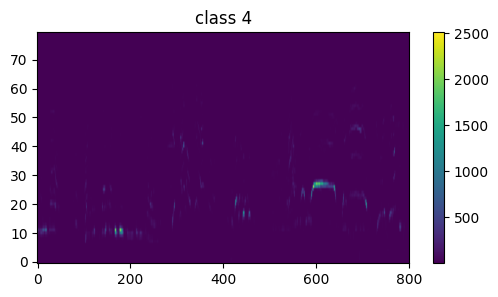

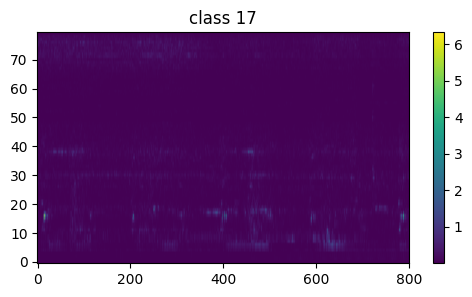

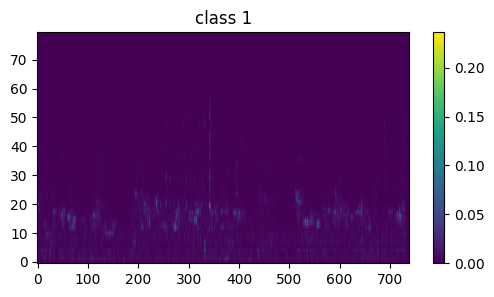

In [12]:
import matplotlib.pyplot as plt

def show_specs(dataset, n_per_class=1):
    seen = {}
    for i in range(len(dataset)):
        x, y = dataset[i]
        y = int(y)
        if y not in seen:
            seen[y] = 0
        if seen[y] >= n_per_class:
            continue

        spec = x.squeeze().cpu().numpy()
        plt.figure(figsize=(6, 3))
        plt.imshow(spec, origin="lower", aspect="auto")
        plt.colorbar()
        plt.title(f"class {y}")
        plt.show()

        seen[y] += 1
        if len(seen) == dataset.classes() and all(v >= n_per_class for v in seen.values()):
            break

show_specs(trainset)